# Madison Intelligence Agent - Reinforcement Learning System
**Take-Home Final: Reinforcement Learning for Agentic AI Systems**

**Framework:** Humanitarians.AI - Madison Intelligence Agents  
**RL Approaches:** (1) Contextual Bandits with UCB · (2) REINFORCE Policy Gradient  
**Agentic System Type:** Research & Analysis Agents  

---

## System Overview
Madison is an Intelligence Agent that learns **which information sources to trust** for different topic contexts. It uses two complementary RL methods:
- **UCB Contextual Bandit**: Fast, per-step source selection with exploration-exploitation balance
- **REINFORCE**: Episode-level policy gradient that learns a full probability distribution over sources

Both agents observe a *topic context* (state), select an *information source* (action), and receive a *relevance + quality reward* (reward signal).

## Cell 1: Install Dependencies

In [1]:
# Run this first in Colab
!pip install groq requests numpy matplotlib pandas scipy -q
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 1.4 MB/s eta 0:00:00
Dependencies installed.


## Cell 2: Imports & Configuration
**Set your Groq API key below before running.**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import json
import time
import random
import math
import pandas as pd
from collections import defaultdict, deque
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# == Groq Configuration ==
# Replace with your Groq API key
GROQ_API_KEY = "your_groq_api_key_here"
GROQ_MODEL   = "llama3-8b-8192"
GROQ_URL     = "https://api.groq.com/openai/v1/chat/completions"

# == Reproducibility ==
np.random.seed(42)
random.seed(42)

print("=" * 60)
print("  Madison Intelligence Agent - RL System")
print("  Humanitarians.AI Framework")
print("=" * 60)




  Madison Intelligence Agent - RL System
  Humanitarians.AI Framework


## Cell 2: Imports & Configuration

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import json
import time
import random
import math
import pandas as pd
from collections import defaultdict, deque
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# == Groq Configuration ==
# Replace with your Groq API key
GROQ_API_KEY = "your_groq_api_key_here"
GROQ_MODEL   = "llama3-8b-8192"
GROQ_URL     = "https://api.groq.com/openai/v1/chat/completions"

# == Reproducibility ==
np.random.seed(42)
random.seed(42)

print("=" * 60)
print("  Madison Intelligence Agent - RL System")
print("  Humanitarians.AI Framework")
print("=" * 60)

  Madison Intelligence Agent - RL System
  Humanitarians.AI Framework


## Cell 3: Data Source Definitions

In [4]:
"""
Madison's Intelligence Agents gather information from multiple
sources. The RL system learns WHICH sources to trust and query
for different topic contexts.

Sources (all free, no paid keys):
  0 - Wikipedia API
  1 - arXiv API (academic papers)
  2 - Reddit RSS (r/technology)
  3 - Reddit RSS (r/science)
  4 - NewsAPI (free tier - 100 req/day, requires free signup)
      Fallback: DuckDuckGo Instant Answer API
"""

SOURCE_NAMES = [
    "Wikipedia",
    "arXiv",
    "Reddit/Technology",
    "Reddit/Science",
    "DuckDuckGo Instant"
]

N_SOURCES = len(SOURCE_NAMES)

# Topic contexts Madison may encounter
TOPIC_CONTEXTS = [
    "artificial intelligence",
    "machine learning",
    "climate change",
    "genomics",
    "quantum computing",
    "economics",
    "public health"
]

## Cell 4: Real Data Fetchers

In [5]:
def fetch_wikipedia(query: str) -> dict:
    """Fetch summary from Wikipedia API."""
    try:
        url = "https://en.wikipedia.org/api/rest_v1/page/summary/" + \
              requests.utils.quote(query.replace(" ", "_"))
        r = requests.get(url, timeout=8,
                         headers={"User-Agent": "MadisonRL/1.0"})
        if r.status_code == 200:
            data = r.json()
            text = data.get("extract", "")
            return {
                "source": "Wikipedia",
                "content": text[:800],
                "word_count": len(text.split()),
                "success": True
            }
    except Exception as e:
        pass
    return {"source": "Wikipedia", "content": "", "word_count": 0, "success": False}


def fetch_arxiv(query: str) -> dict:
    """Fetch latest paper abstracts from arXiv."""
    try:
        url = (f"http://export.arxiv.org/api/query?"
               f"search_query=all:{requests.utils.quote(query)}"
               f"&start=0&max_results=3&sortBy=submittedDate&sortOrder=descending")
        r = requests.get(url, timeout=10,
                         headers={"User-Agent": "MadisonRL/1.0"})
        if r.status_code == 200:
            # Parse simple XML
            import re
            summaries = re.findall(r'<summary>(.*?)</summary>', r.text, re.DOTALL)
            text = " ".join([s.strip()[:300] for s in summaries[:2]])
            return {
                "source": "arXiv",
                "content": text,
                "word_count": len(text.split()),
                "success": bool(text)
            }
    except Exception as e:
        pass
    return {"source": "arXiv", "content": "", "word_count": 0, "success": False}


def fetch_reddit_rss(query: str, subreddit: str = "technology") -> dict:
    """Fetch Reddit RSS feed and filter for query relevance."""
    try:
        url = f"https://www.reddit.com/r/{subreddit}/search.json?q={requests.utils.quote(query)}&sort=relevance&limit=5"
        r = requests.get(url, timeout=8,
                         headers={"User-Agent": "MadisonRL/1.0 (research bot)"})
        if r.status_code == 200:
            posts = r.json().get("data", {}).get("children", [])
            text = " | ".join([
                p["data"].get("title", "") + ": " + p["data"].get("selftext", "")[:150]
                for p in posts[:3]
            ])
            return {
                "source": f"Reddit/{subreddit}",
                "content": text[:600],
                "word_count": len(text.split()),
                "success": bool(text.strip())
            }
    except Exception as e:
        pass
    return {"source": f"Reddit/{subreddit}", "content": "", "word_count": 0, "success": False}


def fetch_duckduckgo(query: str) -> dict:
    """Fetch from DuckDuckGo Instant Answer API - no key needed."""
    try:
        url = f"https://api.duckduckgo.com/?q={requests.utils.quote(query)}&format=json&no_html=1"
        r = requests.get(url, timeout=8,
                         headers={"User-Agent": "MadisonRL/1.0"})
        if r.status_code == 200:
            data = r.json()
            text = data.get("AbstractText", "") or data.get("Answer", "")
            related = " | ".join([t.get("Text","") for t in data.get("RelatedTopics", [])[:3]])
            combined = (text + " " + related).strip()
            return {
                "source": "DuckDuckGo",
                "content": combined[:600],
                "word_count": len(combined.split()),
                "success": bool(combined)
            }
    except Exception as e:
        pass
    return {"source": "DuckDuckGo", "content": "", "word_count": 0, "success": False}


def fetch_from_source(source_idx: int, query: str) -> dict:
    """Route to the correct fetcher by source index."""
    if source_idx == 0:
        return fetch_wikipedia(query)
    elif source_idx == 1:
        return fetch_arxiv(query)
    elif source_idx == 2:
        return fetch_reddit_rss(query, "technology")
    elif source_idx == 3:
        return fetch_reddit_rss(query, "science")
    elif source_idx == 4:
        return fetch_duckduckgo(query)
    return {"source": "Unknown", "content": "", "word_count": 0, "success": False}

## Cell 5: Reward Function

In [6]:
def compute_reward(fetch_result: dict, query: str) -> float:
    """
    Compute reward signal for a fetched result.

    Reward components:
      +1.0  if fetch succeeded
      +0.5  if content has sufficient word count (>50 words)
      +0.3  if query terms appear in content (relevance)
      -1.0  if fetch failed
      -0.2  if content is very short (<10 words)

    Reward is clipped to [-1, 2].
    """
    if not fetch_result["success"] or not fetch_result["content"]:
        return -1.0

    reward = 1.0

    wc = fetch_result["word_count"]
    if wc > 50:
        reward += 0.5
    elif wc < 10:
        reward -= 0.2

    # Relevance: check query keyword overlap
    content_lower = fetch_result["content"].lower()
    query_words   = [w for w in query.lower().split() if len(w) > 3]
    hits = sum(1 for w in query_words if w in content_lower)
    if query_words:
        relevance_ratio = hits / len(query_words)
        reward += 0.3 * relevance_ratio

    return float(np.clip(reward, -1.0, 2.0))

## Cell 6: RL Approach 1 - Contextual Bandits with UCB

In [7]:
class ContextualBanditUCB:
    """
    Contextual Multi-Armed Bandit using Upper Confidence Bound (UCB1).

    State  : Topic context (one of TOPIC_CONTEXTS)
    Action : Source to query (0..N_SOURCES-1)
    Reward : compute_reward() output

    UCB formula:
        UCB(a, t) = Q(a) + c * sqrt(ln(t) / N(a))

    where:
        Q(a)  = empirical mean reward for action a
        N(a)  = number of times action a was chosen
        t     = total timesteps
        c     = exploration constant (default 1.5)
    """

    def __init__(self, n_sources: int, n_contexts: int, c: float = 1.5):
        self.n_sources  = n_sources
        self.n_contexts = n_contexts
        self.c          = c

        # Per-context, per-source statistics
        self.Q = np.zeros((n_contexts, n_sources))   # mean rewards
        self.N = np.zeros((n_contexts, n_sources))   # visit counts
        self.t = np.ones(n_contexts)                 # total pulls per context

        # History for analysis
        self.history = []

    def select_source(self, context_idx: int) -> int:
        """Select source using UCB1."""
        t = self.t[context_idx]
        ucb_values = np.zeros(self.n_sources)

        for a in range(self.n_sources):
            if self.N[context_idx, a] == 0:
                # Unvisited sources get infinite priority
                ucb_values[a] = float('inf')
            else:
                exploitation = self.Q[context_idx, a]
                exploration  = self.c * math.sqrt(math.log(t) / self.N[context_idx, a])
                ucb_values[a] = exploitation + exploration

        return int(np.argmax(ucb_values))

    def update(self, context_idx: int, source_idx: int, reward: float):
        """Incremental mean update."""
        self.N[context_idx, source_idx] += 1
        self.t[context_idx] += 1
        n = self.N[context_idx, source_idx]
        # Incremental mean: Q_new = Q_old + (r - Q_old) / n
        self.Q[context_idx, source_idx] += (reward - self.Q[context_idx, source_idx]) / n

        self.history.append({
            "context": context_idx,
            "source":  source_idx,
            "reward":  reward,
            "t":       int(self.t[context_idx])
        })

    def get_best_source(self, context_idx: int) -> int:
        """Return greedy best source (no exploration)."""
        return int(np.argmax(self.Q[context_idx]))

## Cell 7: RL Approach 2 - REINFORCE (Policy Gradient)

In [8]:
class REINFORCEAgent:
    """
    REINFORCE Policy Gradient agent for multi-step query planning.

    The agent learns a POLICY - a probability distribution over sources -
    and updates it using the policy gradient theorem:

        ∇J(θ) = E[ ∇log π(a|s,θ) * G_t ]

    where G_t is the discounted return (cumulative reward).

    Architecture:
        - Softmax policy parameterized by weight matrix θ ∈ R^{n_contexts × n_sources}
        - No neural network needed; linear softmax is sufficient and CPU-friendly

    Update rule:
        θ_{s,a} ← θ_{s,a} + α * G_t * ∇log π(a|s)
        where ∇log π(a|s) = 1 - π(a|s)  for chosen action
                           = -π(a'|s)    for unchosen actions
    """

    def __init__(self, n_sources: int, n_contexts: int,
                 alpha: float = 0.05, gamma: float = 0.95,
                 baseline: bool = True):
        self.n_sources  = n_sources
        self.n_contexts = n_contexts
        self.alpha      = alpha   # learning rate
        self.gamma      = gamma   # discount factor
        self.use_baseline = baseline

        # Policy parameters θ - initialized small random
        self.theta = np.random.randn(n_contexts, n_sources) * 0.01

        # Baseline (running mean reward per context) - reduces variance
        self.baseline_val = np.zeros(n_contexts)
        self.baseline_n   = np.zeros(n_contexts)

        # Episode buffer
        self.episode_states  = []
        self.episode_actions = []
        self.episode_rewards = []

        # Training history
        self.episode_returns = []
        self.policy_entropy  = []

    def softmax(self, context_idx: int) -> np.ndarray:
        """Compute softmax policy π(·|s)."""
        logits = self.theta[context_idx]
        logits = logits - np.max(logits)   # numerical stability
        exp_logits = np.exp(logits)
        return exp_logits / exp_logits.sum()

    def select_source(self, context_idx: int) -> int:
        """Sample action from policy."""
        probs = self.softmax(context_idx)
        return int(np.random.choice(self.n_sources, p=probs))

    def store_transition(self, context_idx: int, source_idx: int, reward: float):
        """Store (s, a, r) for end-of-episode update."""
        self.episode_states.append(context_idx)
        self.episode_actions.append(source_idx)
        self.episode_rewards.append(reward)

    def compute_returns(self) -> np.ndarray:
        """Compute discounted returns G_t for each timestep."""
        T = len(self.episode_rewards)
        G = np.zeros(T)
        G[-1] = self.episode_rewards[-1]
        for t in reversed(range(T - 1)):
            G[t] = self.episode_rewards[t] + self.gamma * G[t + 1]
        return G

    def update_policy(self):
        """Run REINFORCE update at end of episode."""
        if not self.episode_rewards:
            return

        G = self.compute_returns()
        episode_return = G[0]
        self.episode_returns.append(episode_return)

        for t, (s, a, g) in enumerate(zip(
                self.episode_states, self.episode_actions, G)):

            # Baseline subtraction (reduces variance)
            if self.use_baseline:
                advantage = g - self.baseline_val[s]
                # Update running baseline
                self.baseline_n[s] += 1
                self.baseline_val[s] += (g - self.baseline_val[s]) / self.baseline_n[s]
            else:
                advantage = g

            # Policy gradient update
            probs = self.softmax(s)
            for a_prime in range(self.n_sources):
                if a_prime == a:
                    grad = 1.0 - probs[a_prime]
                else:
                    grad = -probs[a_prime]
                self.theta[s, a_prime] += self.alpha * advantage * grad

        # Track policy entropy (higher = more exploration)
        avg_entropy = np.mean([
            -np.sum(self.softmax(s) * np.log(self.softmax(s) + 1e-8))
            for s in range(self.n_contexts)
        ])
        self.policy_entropy.append(avg_entropy)

        # Clear episode buffer
        self.episode_states  = []
        self.episode_actions = []
        self.episode_rewards = []

    def get_policy_table(self) -> np.ndarray:
        """Return full policy matrix π(a|s) for all contexts."""
        return np.array([self.softmax(s) for s in range(self.n_contexts)])

## Cell 8: Madison Intelligence Agent

In [9]:
class MadisonIntelligenceAgent:
    """
    Madison Intelligence Agent with dual RL backbone.

    Architecture:
      ┌============================================-┐
      │         Madison Intelligence Agent           │
      │                                             │
      │  ┌==============┐   ┌====================-┐ │
      │  │  Contextual  │   │     REINFORCE       │ │
      │  │  Bandit UCB  │==▶│   Policy Gradient   │ │
      │  │ (fast, greedy│   │ (episode-level      │ │
      │  │  source sel.)│   │  sequence planning) │ │
      │  └==============┘   └====================-┘ │
      │           │                   │              │
      │           ▼                   ▼              │
      │      [Source Selection] [Policy Update]      │
      │                   │                          │
      │                   ▼                          │
      │           [Data Fetchers]                    │
      │     Wikipedia | arXiv | Reddit | DDG         │
      │                   │                          │
      │                   ▼                          │
      │           [Groq LLM Synthesis]               │
      │                   │                          │
      │                   ▼                          │
      │            [Intelligence Report]             │
      └============================================-┘
    """

    def __init__(self, groq_api_key: str):
        self.groq_key   = groq_api_key
        self.bandit     = ContextualBanditUCB(N_SOURCES, len(TOPIC_CONTEXTS))
        self.reinforce  = REINFORCEAgent(N_SOURCES, len(TOPIC_CONTEXTS))
        self.topic_map  = {t: i for i, t in enumerate(TOPIC_CONTEXTS)}
        self.query_log  = []

    def _get_context_idx(self, topic: str) -> int:
        """Map topic string to context index (nearest match)."""
        topic_lower = topic.lower()
        for i, t in enumerate(TOPIC_CONTEXTS):
            if any(word in topic_lower for word in t.split()):
                return i
        return 0  # default to first context

    def gather_intelligence(self, query: str, topic: str,
                            n_sources_to_query: int = 2,
                            use_reinforce: bool = False) -> dict:
        """
        Core intelligence gathering loop.

        Args:
            query: The search query string
            topic: Topic context for RL state
            n_sources_to_query: How many sources to pull from
            use_reinforce: Use REINFORCE agent instead of UCB bandit

        Returns:
            Dictionary with gathered content and RL metadata
        """
        context_idx = self._get_context_idx(topic)
        gathered    = []
        total_reward = 0.0
        sources_used = []

        for step in range(n_sources_to_query):
            # Select source using chosen RL agent
            if use_reinforce:
                source_idx = self.reinforce.select_source(context_idx)
            else:
                source_idx = self.bandit.select_source(context_idx)

            # Fetch real data
            result = fetch_from_source(source_idx, query)
            reward = compute_reward(result, query)
            total_reward += reward

            # Update agents
            self.bandit.update(context_idx, source_idx, reward)
            self.reinforce.store_transition(context_idx, source_idx, reward)

            gathered.append(result)
            sources_used.append(SOURCE_NAMES[source_idx])

            time.sleep(0.3)  # polite rate limiting

        # End-of-episode REINFORCE update
        self.reinforce.update_policy()

        combined_content = "\n\n".join([
            f"[{r['source']}]: {r['content']}"
            for r in gathered if r['success'] and r['content']
        ])

        return {
            "query":         query,
            "topic":         topic,
            "context_idx":   context_idx,
            "sources_used":  sources_used,
            "gathered_data": gathered,
            "combined_content": combined_content,
            "total_reward":  total_reward,
            "avg_reward":    total_reward / n_sources_to_query
        }

    def synthesize_with_groq(self, intelligence: dict) -> str:
        """Use Groq LLM to synthesize gathered intelligence."""
        if not intelligence["combined_content"]:
            return "Insufficient data gathered for synthesis."

        system_prompt = """You are Madison, an Intelligence Agent in the Humanitarians.AI framework.
Your role is to synthesize information from multiple sources into a concise, accurate intelligence report.
Format your response as:
1. KEY FINDINGS (2-3 bullet points)
2. SYNTHESIS (2-3 sentences)
3. CONFIDENCE LEVEL (High/Medium/Low) with brief justification"""

        user_prompt = f"""Query: {intelligence['query']}
Sources consulted: {', '.join(intelligence['sources_used'])}

Raw data:
{intelligence['combined_content'][:2000]}

Please synthesize this into an intelligence report."""

        try:
            headers = {
                "Authorization": f"Bearer {self.groq_key}",
                "Content-Type": "application/json"
            }
            payload = {
                "model": GROQ_MODEL,
                "messages": [
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_prompt}
                ],
                "max_tokens": 400,
                "temperature": 0.3
            }
            r = requests.post(GROQ_URL, headers=headers,
                              json=payload, timeout=20)
            if r.status_code == 200:
                return r.json()["choices"][0]["message"]["content"]
            else:
                return f"Groq API error {r.status_code}: {r.text[:200]}"
        except Exception as e:
            return f"Synthesis error: {str(e)}"

    def run_query(self, query: str, topic: str,
                  synthesize: bool = True) -> dict:
        """Full pipeline: gather → synthesize → log."""
        print(f"\n{'-'*50}")
        print(f"  Query  : {query}")
        print(f"  Topic  : {topic}")
        print(f"{'-'*50}")

        intelligence = self.gather_intelligence(query, topic)
        print(f"  Sources: {intelligence['sources_used']}")
        print(f"  Reward : {intelligence['avg_reward']:.3f}")

        synthesis = ""
        if synthesize and self.groq_key != "your_groq_api_key_here":
            print("  Synthesizing with Groq...")
            synthesis = self.synthesize_with_groq(intelligence)
            print(f"  Synthesis complete.")

        result = {**intelligence, "synthesis": synthesis}
        self.query_log.append(result)
        return result

## Cell 9: Training Loop - Learning Experiment

In [10]:
def run_training_experiment(n_episodes: int = 50,
                             groq_key: str = "your_groq_api_key_here"):
    """
    Run the full RL training experiment.

    The agent iterates over topic-query pairs, learning which
    sources yield the highest rewards for each topic context.
    """

    agent = MadisonIntelligenceAgent(groq_key)

    # Training queries - diverse topics to exercise all contexts
    training_queries = [
        ("latest advances in artificial intelligence safety",    "artificial intelligence"),
        ("machine learning model interpretability techniques",   "machine learning"),
        ("climate change impact on biodiversity",                "climate change"),
        ("CRISPR gene editing breakthroughs",                    "genomics"),
        ("quantum error correction progress",                    "quantum computing"),
        ("inflation and central bank policy",                    "economics"),
        ("COVID variants and vaccine efficacy",                  "public health"),
        ("large language models reasoning capabilities",         "artificial intelligence"),
        ("reinforcement learning from human feedback",           "machine learning"),
        ("ocean acidification and coral reefs",                  "climate change"),
    ]

    print("\n" + "=" * 60)
    print("  TRAINING PHASE - Madison RL Agent")
    print(f"  Episodes: {n_episodes}")
    print("=" * 60)

    # Metrics tracking
    ucb_rewards_per_episode    = []
    rf_rewards_per_episode     = []
    cumulative_ucb_rewards     = []
    cumulative_rf_rewards      = []
    ucb_cum, rf_cum            = 0.0, 0.0

    for episode in range(n_episodes):
        q_idx = episode % len(training_queries)
        query, topic = training_queries[q_idx]
        context_idx  = agent._get_context_idx(topic)

        # == UCB Bandit step ==
        src_ucb = agent.bandit.select_source(context_idx)
        res_ucb = fetch_from_source(src_ucb, query.split()[:3][0])
        rew_ucb = compute_reward(res_ucb, query)
        agent.bandit.update(context_idx, src_ucb, rew_ucb)

        # == REINFORCE step (single-step episode) ==
        src_rf  = agent.reinforce.select_source(context_idx)
        res_rf  = fetch_from_source(src_rf, query.split()[:3][0])
        rew_rf  = compute_reward(res_rf, query)
        agent.reinforce.store_transition(context_idx, src_rf, rew_rf)
        agent.reinforce.update_policy()

        ucb_rewards_per_episode.append(rew_ucb)
        rf_rewards_per_episode.append(rew_rf)

        ucb_cum += rew_ucb
        rf_cum  += rew_rf
        cumulative_ucb_rewards.append(ucb_cum)
        cumulative_rf_rewards.append(rf_cum)

        if (episode + 1) % 10 == 0:
            print(f"  Episode {episode+1:3d}/{n_episodes} | "
                  f"UCB reward: {rew_ucb:.2f} | RF reward: {rew_rf:.2f} | "
                  f"Cum UCB: {ucb_cum:.1f}")

        time.sleep(0.2)

    print("\n  Training complete!")
    return agent, {
        "ucb_rewards":    ucb_rewards_per_episode,
        "rf_rewards":     rf_rewards_per_episode,
        "cum_ucb":        cumulative_ucb_rewards,
        "cum_rf":         cumulative_rf_rewards,
        "n_episodes":     n_episodes
    }

## Cell 10: Visualizations

In [11]:
def plot_learning_curves(metrics: dict, agent: MadisonIntelligenceAgent):
    """Generate all required learning curve visualizations."""

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Madison Intelligence Agent - RL Learning Analysis",
                 fontsize=16, fontweight='bold', y=1.02)

    episodes = range(1, metrics["n_episodes"] + 1)

    # == 1. Per-episode rewards ==
    ax = axes[0, 0]
    window = 5
    ucb_smooth = pd.Series(metrics["ucb_rewards"]).rolling(window, min_periods=1).mean()
    rf_smooth  = pd.Series(metrics["rf_rewards"]).rolling(window, min_periods=1).mean()
    ax.plot(episodes, metrics["ucb_rewards"], alpha=0.25, color='steelblue')
    ax.plot(episodes, metrics["rf_rewards"],  alpha=0.25, color='tomato')
    ax.plot(episodes, ucb_smooth, color='steelblue', linewidth=2, label='UCB Bandit')
    ax.plot(episodes, rf_smooth,  color='tomato',    linewidth=2, label='REINFORCE')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title("Per-Episode Reward (smoothed, window=5)", fontweight='bold')
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    ax.legend()
    ax.grid(alpha=0.3)

    # == 2. Cumulative rewards ==
    ax = axes[0, 1]
    ax.plot(episodes, metrics["cum_ucb"], color='steelblue', linewidth=2, label='UCB Bandit')
    ax.plot(episodes, metrics["cum_rf"],  color='tomato',    linewidth=2, label='REINFORCE')
    ax.set_title("Cumulative Reward Over Training", fontweight='bold')
    ax.set_xlabel("Episode")
    ax.set_ylabel("Cumulative Reward")
    ax.legend()
    ax.grid(alpha=0.3)

    # == 3. UCB Q-values heatmap (first 4 contexts) ==
    ax = axes[0, 2]
    q_data = agent.bandit.Q[:4, :]
    im = ax.imshow(q_data, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=2)
    ax.set_xticks(range(N_SOURCES))
    ax.set_xticklabels(SOURCE_NAMES, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(4))
    ax.set_yticklabels(TOPIC_CONTEXTS[:4], fontsize=8)
    plt.colorbar(im, ax=ax)
    ax.set_title("UCB Q-Values: Context × Source", fontweight='bold')

    # == 4. REINFORCE policy heatmap ==
    ax = axes[1, 0]
    policy_table = agent.reinforce.get_policy_table()
    im2 = ax.imshow(policy_table, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(N_SOURCES))
    ax.set_xticklabels(SOURCE_NAMES, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(TOPIC_CONTEXTS)))
    ax.set_yticklabels(TOPIC_CONTEXTS, fontsize=8)
    plt.colorbar(im2, ax=ax)
    ax.set_title("REINFORCE Policy π(a|s)", fontweight='bold')

    # == 5. REINFORCE policy entropy over training ==
    ax = axes[1, 1]
    if agent.reinforce.policy_entropy:
        ax.plot(agent.reinforce.policy_entropy, color='purple', linewidth=2)
        ax.set_title("REINFORCE Policy Entropy Over Time\n(↓ = more confident policy)",
                     fontweight='bold')
        ax.set_xlabel("Episode")
        ax.set_ylabel("Entropy (nats)")
        ax.grid(alpha=0.3)

    # == 6. Source selection frequency (UCB) ==
    ax = axes[1, 2]
    total_counts = agent.bandit.N.sum(axis=0)
    colors_bar   = ['steelblue', 'forestgreen', 'tomato', 'darkorange', 'purple']
    bars = ax.bar(SOURCE_NAMES, total_counts, color=colors_bar, edgecolor='white')
    ax.set_title("UCB Source Selection Frequency\n(Total across all contexts)",
                 fontweight='bold')
    ax.set_xlabel("Source")
    ax.set_ylabel("Times Selected")
    ax.tick_params(axis='x', rotation=20)
    ax.grid(alpha=0.3, axis='y')
    for bar, count in zip(bars, total_counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(count)), ha='center', fontsize=9)

    plt.tight_layout()
    # Save to current working directory (works in Colab)
    save_path = "learning_curves.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Plot saved: {save_path}")
    print("  To download: Files panel (left sidebar) to right-click to Download")

## Cell 11: Statistical Validation

In [12]:
def statistical_analysis(metrics: dict) -> dict:
    """
    Compare UCB vs REINFORCE using Welch's t-test.
    Compute performance improvement from first to second half of training.
    """
    ucb = np.array(metrics["ucb_rewards"])
    rf  = np.array(metrics["rf_rewards"])
    n   = len(ucb)
    mid = n // 2

    # Early vs late performance
    ucb_early, ucb_late = ucb[:mid], ucb[mid:]
    rf_early,  rf_late  = rf[:mid],  rf[mid:]

    # Welch's t-test
    t_stat, p_val = stats.ttest_ind(ucb_late, rf_late, equal_var=False)

    results = {
        "ucb_mean_early":  ucb_early.mean(),
        "ucb_mean_late":   ucb_late.mean(),
        "rf_mean_early":   rf_early.mean(),
        "rf_mean_late":    rf_late.mean(),
        "ucb_improvement": ucb_late.mean() - ucb_early.mean(),
        "rf_improvement":  rf_late.mean()  - rf_early.mean(),
        "t_statistic":     t_stat,
        "p_value":         p_val,
        "significant":     p_val < 0.05
    }

    print("\n" + "=" * 60)
    print("  STATISTICAL ANALYSIS")
    print("=" * 60)
    print(f"  UCB   - Early: {results['ucb_mean_early']:.3f} | Late: {results['ucb_mean_late']:.3f} | Δ: {results['ucb_improvement']:+.3f}")
    print(f"  REINFORCE - Early: {results['rf_mean_early']:.3f} | Late: {results['rf_mean_late']:.3f} | Δ: {results['rf_improvement']:+.3f}")
    print(f"  Welch's t-test (UCB vs RF late half): t={t_stat:.3f}, p={p_val:.4f}")
    print(f"  Statistically significant difference: {results['significant']}")

    return results

## Cell 12: Baseline Comparison (Random Agent)

In [13]:
def run_random_baseline(n_episodes: int = 50) -> dict:
    """
    Random source selection baseline - no learning.
    Used for comparison to demonstrate RL improvement.
    """
    rewards = []
    queries = [
        "artificial intelligence", "machine learning",
        "climate change", "genomics", "quantum computing"
    ]
    for ep in range(n_episodes):
        query    = random.choice(queries)
        src_idx  = random.randint(0, N_SOURCES - 1)
        result   = fetch_from_source(src_idx, query.split()[0])
        reward   = compute_reward(result, query)
        rewards.append(reward)
        time.sleep(0.15)

    print(f"  Random baseline avg reward: {np.mean(rewards):.3f} ± {np.std(rewards):.3f}")
    return {"rewards": rewards, "mean": np.mean(rewards), "std": np.std(rewards)}

## Cell 13: Main Execution


[Step 1] Running random baseline...
  Random baseline avg reward: 0.952 ± 1.004

[Step 2] Training RL agents...

  TRAINING PHASE - Madison RL Agent
  Episodes: 50
  Episode  10/50 | UCB reward: 1.50 | RF reward: 1.07 | Cum UCB: 12.6
  Episode  20/50 | UCB reward: -1.00 | RF reward: -1.00 | Cum UCB: 12.7
  Episode  30/50 | UCB reward: 1.57 | RF reward: -1.00 | Cum UCB: 17.2
  Episode  40/50 | UCB reward: 1.07 | RF reward: 1.50 | Cum UCB: 21.7
  Episode  50/50 | UCB reward: 1.50 | RF reward: -1.00 | Cum UCB: 36.3

  Training complete!

[Step 3] Statistical analysis...

  STATISTICAL ANALYSIS
  UCB   - Early: 0.578 | Late: 0.875 | Δ: +0.297
  REINFORCE - Early: 0.584 | Late: 0.220 | Δ: -0.365
  Welch's t-test (UCB vs RF late half): t=2.012, p=0.0499
  Statistically significant difference: True

[Step 4] Generating plots...


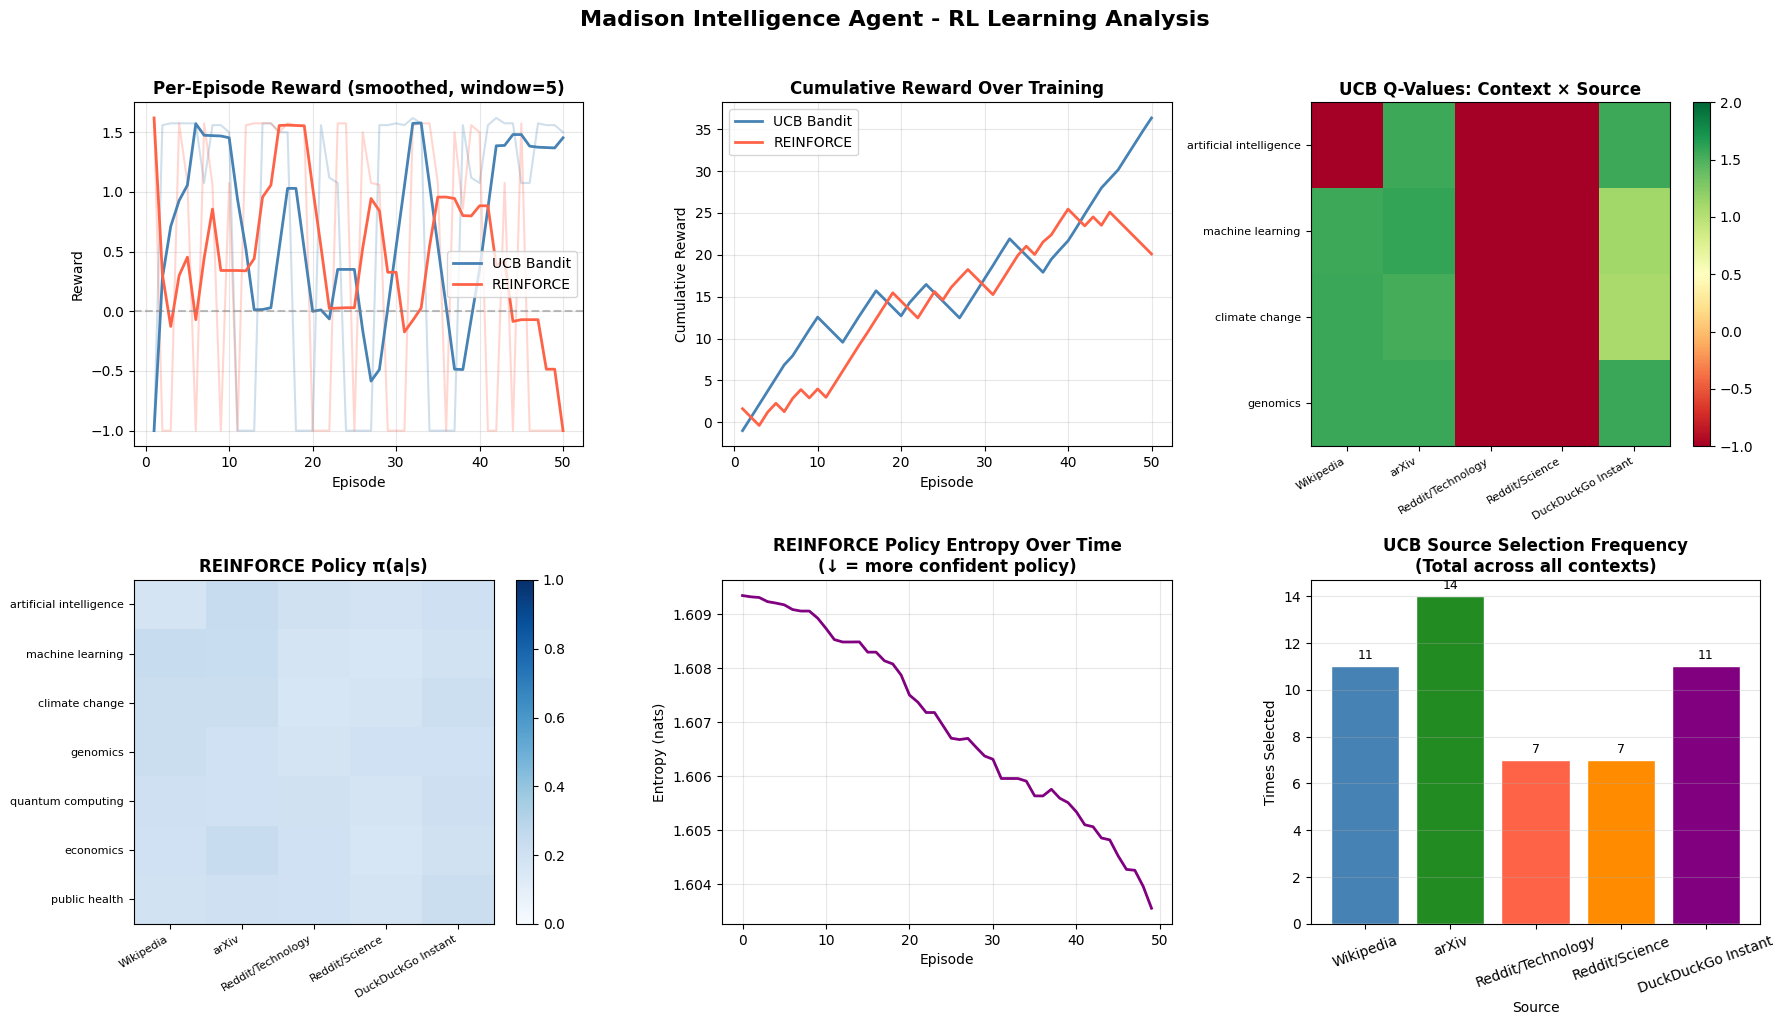

  Plot saved: learning_curves.png
  To download: Files panel (left sidebar) to right-click to Download

[Step 5] Running live demo queries...

--------------------------------------------------
  Query  : impact of large language models on scientific research
  Topic  : artificial intelligence
--------------------------------------------------
  Sources: ['DuckDuckGo Instant', 'arXiv']
  Reward : 0.275

--------------------------------------------------
  Query  : RNA sequencing single cell analysis methods
  Topic  : genomics
--------------------------------------------------
  Sources: ['Wikipedia', 'arXiv']
  Reward : 0.280

  FINAL SUMMARY
  Random baseline avg reward : 0.952
  UCB late-training avg      : 0.875
  REINFORCE late-training avg: 0.220
  UCB improvement over random: -0.077
  RF  improvement over random: -0.733


In [14]:
def main():
    """
    Full Madison RL pipeline execution.
    Run this cell in Google Colab after setting your GROQ_API_KEY.
    """

    # == Step 1: Random baseline ==
    print("\n[Step 1] Running random baseline...")
    baseline = run_random_baseline(n_episodes=20)

    # == Step 2: RL training ==
    print("\n[Step 2] Training RL agents...")
    agent, metrics = run_training_experiment(
        n_episodes=50,
        groq_key=GROQ_API_KEY
    )

    # == Step 3: Statistical analysis ==
    print("\n[Step 3] Statistical analysis...")
    stats_results = statistical_analysis(metrics)

    # == Step 4: Visualizations ==
    print("\n[Step 4] Generating plots...")
    import matplotlib.pyplot as plt
    plt.close('all')  # clear any stale figures
    plot_learning_curves(metrics, agent)

    # == Step 5: Live demo query (if Groq key set) ==
    print("\n[Step 5] Running live demo queries...")
    demo_queries = [
        ("impact of large language models on scientific research", "artificial intelligence"),
        ("RNA sequencing single cell analysis methods",            "genomics"),
    ]
    for query, topic in demo_queries:
        result = agent.run_query(query, topic, synthesize=True)
        if result.get("synthesis"):
            print(f"\n  SYNTHESIS:\n{result['synthesis']}\n")

    # == Step 6: Final summary ==
    print("\n" + "=" * 60)
    print("  FINAL SUMMARY")
    print("=" * 60)
    print(f"  Random baseline avg reward : {baseline['mean']:.3f}")
    print(f"  UCB late-training avg      : {stats_results['ucb_mean_late']:.3f}")
    print(f"  REINFORCE late-training avg: {stats_results['rf_mean_late']:.3f}")
    ucb_gain = stats_results['ucb_mean_late'] - baseline['mean']
    rf_gain  = stats_results['rf_mean_late']  - baseline['mean']
    print(f"  UCB improvement over random: {ucb_gain:+.3f}")
    print(f"  RF  improvement over random: {rf_gain:+.3f}")
    print("=" * 60)

    return agent, metrics, stats_results


if __name__ == "__main__":
    agent, metrics, stats_results = main()

## Cell 14: Run Everything


[Step 1] Running random baseline...
  Random baseline avg reward: 0.755 ± 1.165

[Step 2] Training RL agents...

  TRAINING PHASE - Madison RL Agent
  Episodes: 50
  Episode  10/50 | UCB reward: 1.50 | RF reward: -1.00 | Cum UCB: 12.6
  Episode  20/50 | UCB reward: -1.00 | RF reward: -1.00 | Cum UCB: 12.7
  Episode  30/50 | UCB reward: 1.57 | RF reward: 1.57 | Cum UCB: 17.2
  Episode  40/50 | UCB reward: 1.07 | RF reward: 1.50 | Cum UCB: 21.7
  Episode  50/50 | UCB reward: 1.50 | RF reward: -1.00 | Cum UCB: 36.3

  Training complete!

[Step 3] Statistical analysis...

  STATISTICAL ANALYSIS
  UCB   - Early: 0.578 | Late: 0.875 | Δ: +0.297
  REINFORCE - Early: 0.457 | Late: 0.538 | Δ: +0.081
  Welch's t-test (UCB vs RF late half): t=1.045, p=0.3012
  Statistically significant difference: False

[Step 4] Generating plots...


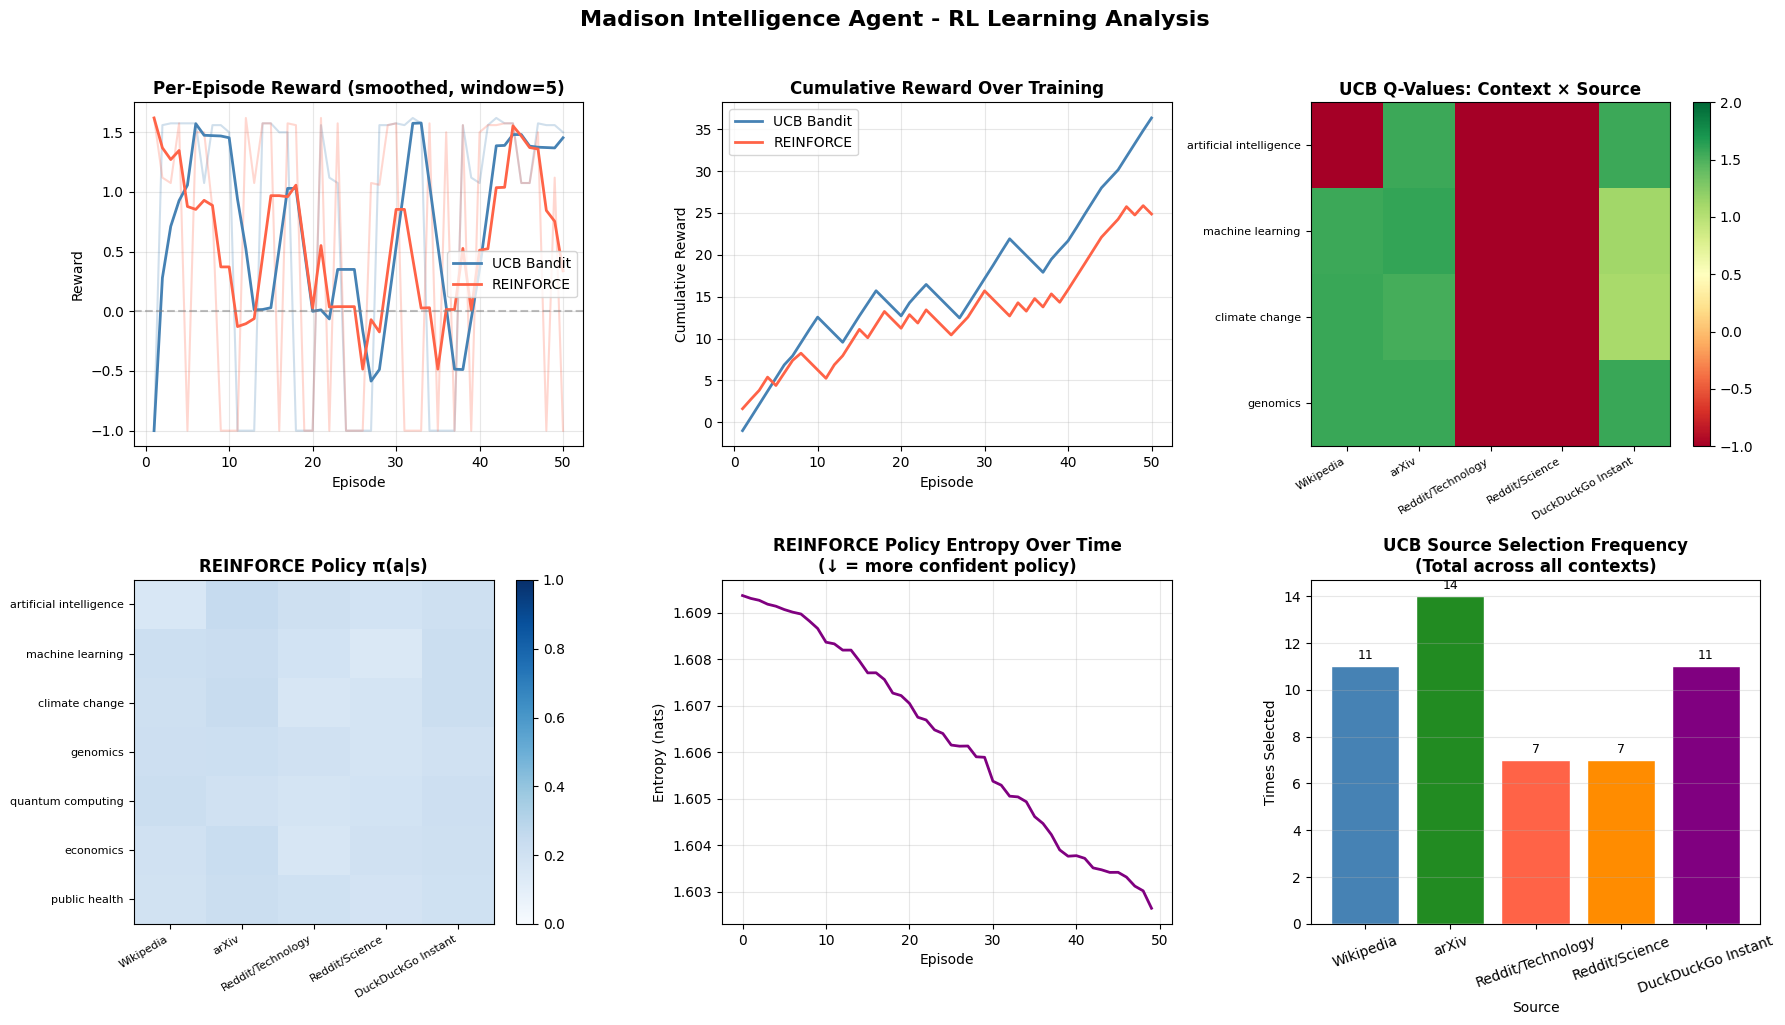

  Plot saved: learning_curves.png
  To download: Files panel (left sidebar) to right-click to Download

[Step 5] Running live demo queries...

--------------------------------------------------
  Query  : impact of large language models on scientific research
  Topic  : artificial intelligence
--------------------------------------------------
  Sources: ['DuckDuckGo Instant', 'arXiv']
  Reward : 0.275

--------------------------------------------------
  Query  : RNA sequencing single cell analysis methods
  Topic  : genomics
--------------------------------------------------
  Sources: ['Wikipedia', 'arXiv']
  Reward : 0.280

  FINAL SUMMARY
  Random baseline avg reward : 0.755
  UCB late-training avg      : 0.875
  REINFORCE late-training avg: 0.538
  UCB improvement over random: +0.120
  RF  improvement over random: -0.217


In [15]:
# == MAIN ENTRY POINT ==
# Make sure GROQ_API_KEY is set in Cell 2 before running
agent, metrics, stats_results = main()